In [1]:
%load_ext autoreload
%autoreload 2

In [25]:
import numpy as np
from wrf_io import postproc
from scipy.io import loadmat
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import mean_squared_error

In [3]:
base_path = '/home1/09909/smata/dir_scratch/induction_modeling/gaussian_process/10MW'

In [26]:
orig_kernel, opt_kernel_rot = postproc.build_kernel_from_search(base_path + '/results/annulus/wrf_10MW_ann_D3_result.txt')

Kernel line:
ScoredKernel(k_opt=ProductKernel([ MaskKernel(ndim=4, active_dimension=3, base_kernel=RQKernel(lengthscale=1.324849, output_variance=1.351125, alpha=-7.592493)), SumKernel([ MaskKernel(ndim=4, active_dimension=0, base_kernel=RQKernel(lengthscale=-1.909702, output_variance=-1.735414, alpha=-1.059517)), MaskKernel(ndim=4, active_dimension=2, base_kernel=SqExpKernel(lengthscale=0.054731, output_variance=-0.782411)) ]) ]), nll=-4323.079816, laplace_nle=nan, bic_nle=-8594.351014, noise=[-4.26192917])

Noise:
-4.26192917

Kernel specification string:
ProductKernel([ MaskKernel(ndim=4, active_dimension=3, base_kernel=RQKernel(lengthscale=1.324849, output_variance=1.351125, alpha=-7.592493)), SumKernel([ MaskKernel(ndim=4, active_dimension=0, base_kernel=RQKernel(lengthscale=-1.909702, output_variance=-1.735414, alpha=-1.059517)), MaskKernel(ndim=4, active_dimension=2, base_kernel=SqExpKernel(lengthscale=0.054731, output_variance=-0.782411)) ]) ])

Kernel structure:
{'children': [

In [27]:
postproc.compare_kernel_dict_and_sklearn(orig_kernel, opt_kernel_rot, tol=0.1, verbose=True)

root: PRODUCT: dict children: [{'type': 'mask', 'ndim': 4, 'active_dimension': 3, 'base_kernel': {'type': 'rq', 'lengthscale': 1.324849, 'variance': 1.351125, 'alpha': -7.592493}}, {'type': 'sum', 'children': [{'type': 'mask', 'ndim': 4, 'active_dimension': 0, 'base_kernel': {'type': 'rq', 'lengthscale': -1.909702, 'variance': -1.735414, 'alpha': -1.059517}}, {'type': 'mask', 'ndim': 4, 'active_dimension': 2, 'base_kernel': {'type': 'sqexp', 'lengthscale': 0.054731, 'variance': -0.782411}}]}]
root: PRODUCT: sk_children: [MaskedKernel(1.97**2 * RationalQuadratic(alpha=0.000504, length_scale=3.76), active_dims=[3]) * MaskedKernel(0.42**2 * RationalQuadratic(alpha=0.347, length_scale=0.148), active_dims=[0]) + MaskedKernel(0.676**2 * RBF(length_scale=1.06), active_dims=[2]), WhiteKernel(noise_level=0.0141)]
root.product[0]: Not a MaskedKernel, got MaskedKernel(1.97**2 * RationalQuadratic(alpha=0.000504, length_scale=3.76), active_dims=[3]) * MaskedKernel(0.42**2 * RationalQuadratic(alpha=

False

In [28]:
K = opt_kernel_rot

print(type(K))
print(hasattr(K, 'kernels'), K.kernels if hasattr(K, 'kernels') else None)
if hasattr(K, 'k1'):
    print("K1 is: ", K.k1)
if hasattr(K, 'k2'):
    print("K2 is: ", K.k2)

<class 'sklearn.gaussian_process.kernels.Sum'>
False None
K1 is:  MaskedKernel(1.97**2 * RationalQuadratic(alpha=0.000504, length_scale=3.76), active_dims=[3]) * MaskedKernel(0.42**2 * RationalQuadratic(alpha=0.347, length_scale=0.148), active_dims=[0]) + MaskedKernel(0.676**2 * RBF(length_scale=1.06), active_dims=[2])
K2 is:  WhiteKernel(noise_level=0.0141)


In [6]:
# Load training data
X_train_rot = loadmat(base_path + '/train_data/wrf_10MW_ann.mat')

X_rot = X_train_rot['X']
y_rot = X_train_rot['y'].ravel()

In [7]:
# Train the GP model
gpr = GaussianProcessRegressor(kernel=opt_kernel_rot, optimizer=None, normalize_y=False)
# gpr = GaussianProcessRegressor(kernel=opt_kernel_rot, optimizer='fmin', normalize_y=False)
gpr.fit(X_rot, y_rot)

GaussianProcessRegressor(kernel=MaskedKernel(0.882**2 * RationalQuadratic(alpha=0.00908, length_scale=0.00347), active_dims=[2]) * MaskedKernel(1.99**2 * RationalQuadratic(alpha=0.000563, length_scale=5.89), active_dims=[3]) * MaskedKernel(0.585**2 * RBF(length_scale=1.21), active_dims=[2]) + MaskedKernel(DotProduct(sigma_0=6.16e-05), active_dims=[0]) * MaskedKernel(0.492**2 * RationalQuadratic(alpha=0.296, length_scale=0.127), active_dims=[0]) + WhiteKernel(noise_level=0.00014),
                         optimizer=None)

In [8]:
# Load test data
X_test_rot = loadmat(base_path + '/test_data/wrf_10MW_ann.mat')
import pickle

# Replace with the actual file path
with open(base_path + '/train_data/scaler_wrf_cot_rot.pkl', 'rb') as f:
    obj_cot1 = pickle.load(f)

with open(base_path + '/train_data/scaler_shears_rot.pkl', 'rb') as f:
    obj_cot2 = pickle.load(f)

with open(base_path + '/train_data/scaler_veers_rot.pkl', 'rb') as f:
    obj_cot3 = pickle.load(f)

with open(base_path + '/train_data/scaler_wrf_ind_rot.pkl', 'rb') as f:
    obj_ann = pickle.load(f)

# X_t_rot = np.zeros((90,3))
# X_t_rot[:,0] = obj_cot1.inverse_transform(X_test_rot['X'][:,0].reshape(-1, 1)).ravel()
# X_t_rot[:,1] = obj_cot2.inverse_transform(X_test_rot['X'][:,1].reshape(-1, 1)).ravel()
# X_t_rot[:,2] = obj_cot3.inverse_transform(X_test_rot['X'][:,2].reshape(-1, 1)).ravel()
# y_t_rot = obj_ann.inverse_transform(X_test_rot['y'])
X_t_rot = X_test_rot['X']
y_t_rot = X_test_rot['y']

In [ ]:
X_t_rot

array([[ 0.04288751, -1.27027842, -1.75      , -2.30089497],
       [ 0.04288751, -1.25821198, -1.75      , -1.38053698],
       [ 0.04288751, -1.25408545, -1.75      , -0.69026849],
       ...,
       [ 0.98123309, -2.00522918,  1.75      ,  0.69026849],
       [ 0.98123309, -2.00466749,  1.75      ,  1.38053698],
       [ 0.98123309, -2.00478388,  1.75      ,  2.30089497]],
      shape=(2340, 4))

In [9]:
A_pred, sigma = gpr.predict(X_t_rot, return_std=True)

X_t_rot = np.zeros((2340,4))
X_t_rot[:,0] = X_test_rot['X'][:,0].reshape(-1, 1).ravel()
X_t_rot[:,1] = obj_cot1.inverse_transform(X_test_rot['X'][:,1].reshape(-1, 1)).ravel()
X_t_rot[:,2] = obj_cot2.inverse_transform(X_test_rot['X'][:,2].reshape(-1, 1)).ravel()
X_t_rot[:,3] = obj_cot3.inverse_transform(X_test_rot['X'][:,3].reshape(-1, 1)).ravel()
y_t_rot = obj_ann.inverse_transform(X_test_rot['y'])

# X_t_rot = obj_cot.inverse_transform(X_test_rot['X'])
# y_t_rot = obj_ann.inverse_transform(X_test_rot['y'])
A_pred = obj_ann.inverse_transform(A_pred.reshape(-1, 1))

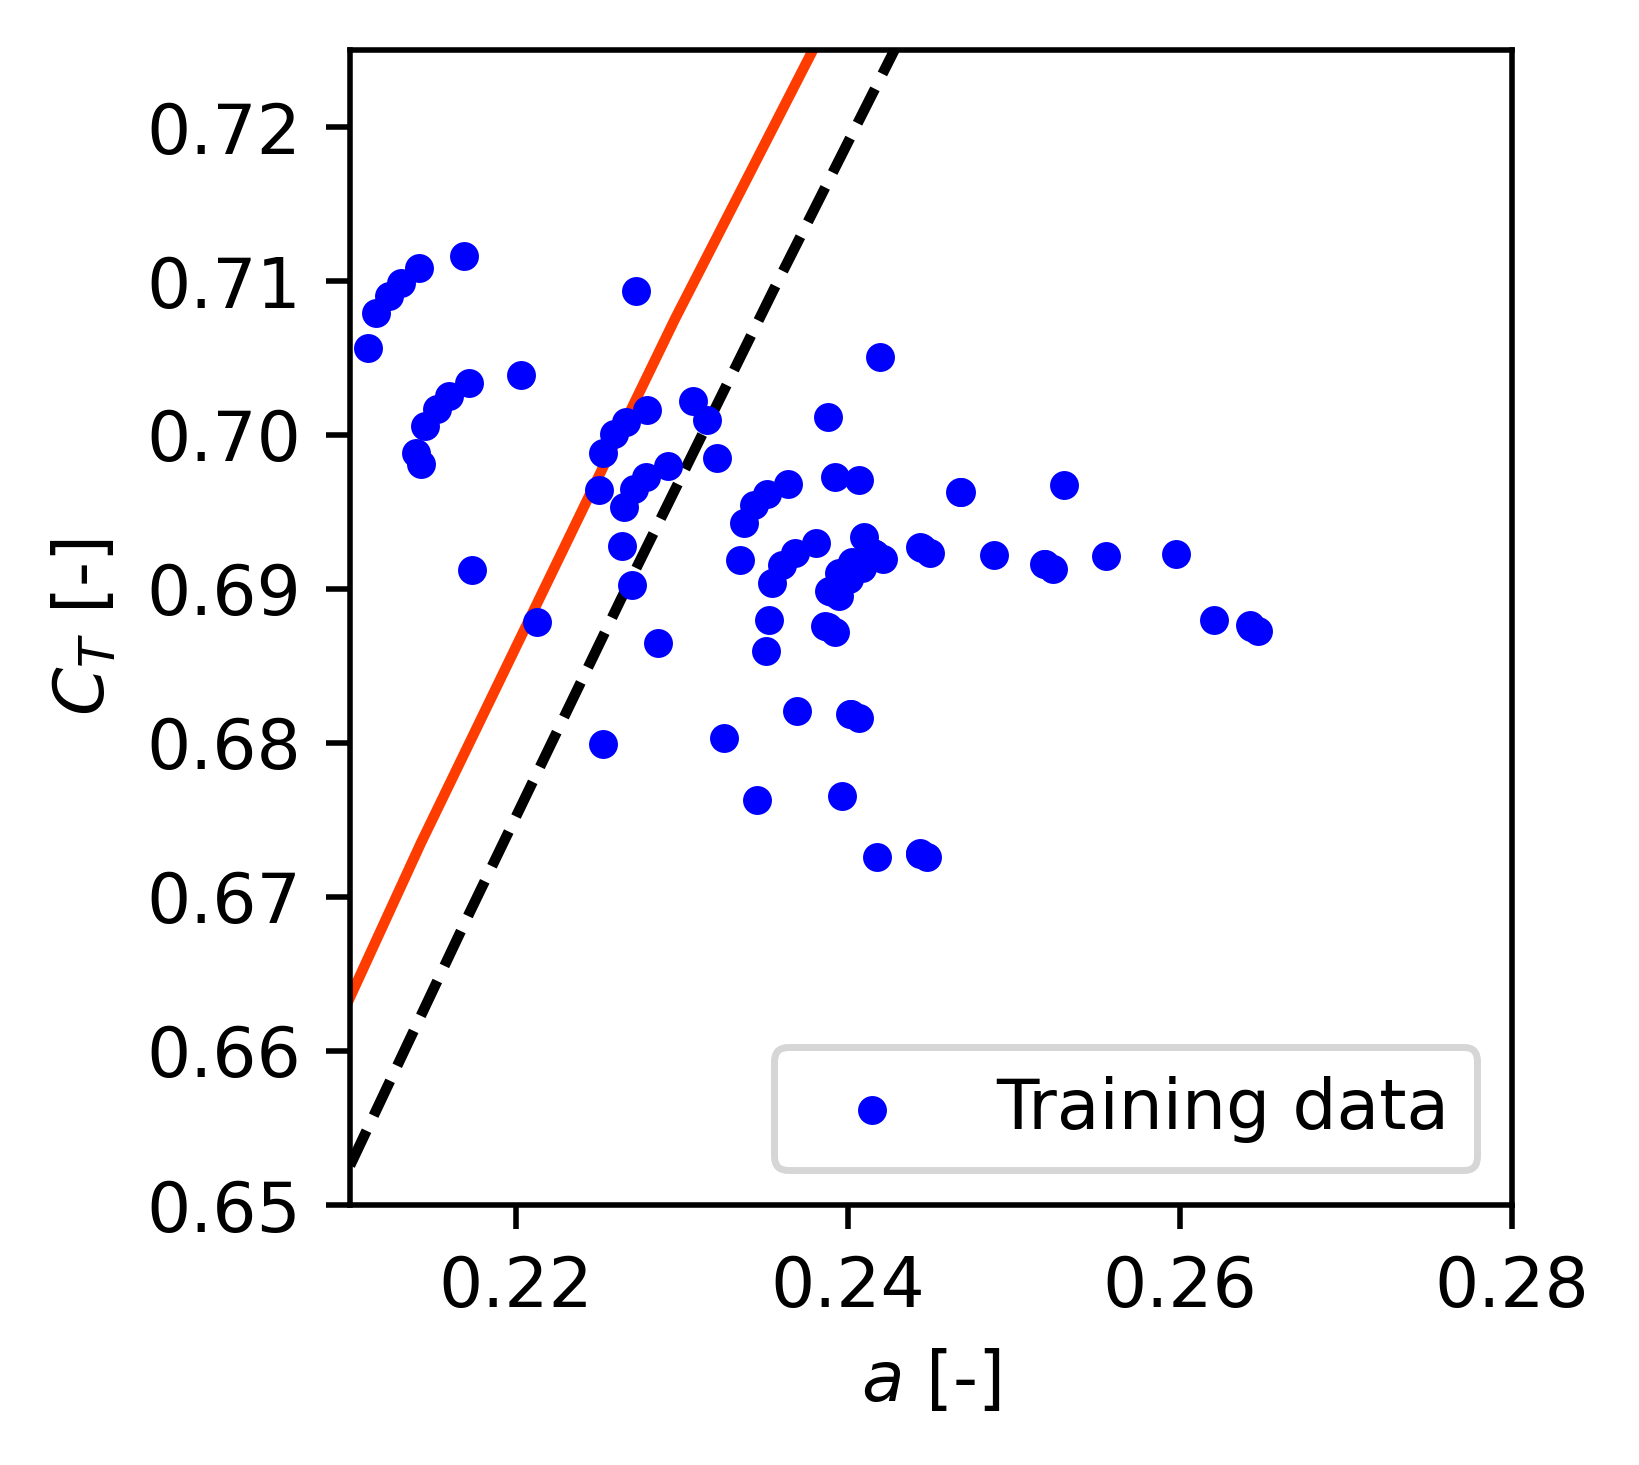

In [ ]:

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(3, 5))

# ax.plot(a_mom,ct_mom,'#ff3c00',zorder=1)
# ax.plot(a_mad,ct_mad,'k--',zorder=1)
ax.scatter(y_t_rot,X_t_rot[:,0],10,color='b',label='Training data')

ax.set_xlim([0.21,0.28])
ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

ax.legend()

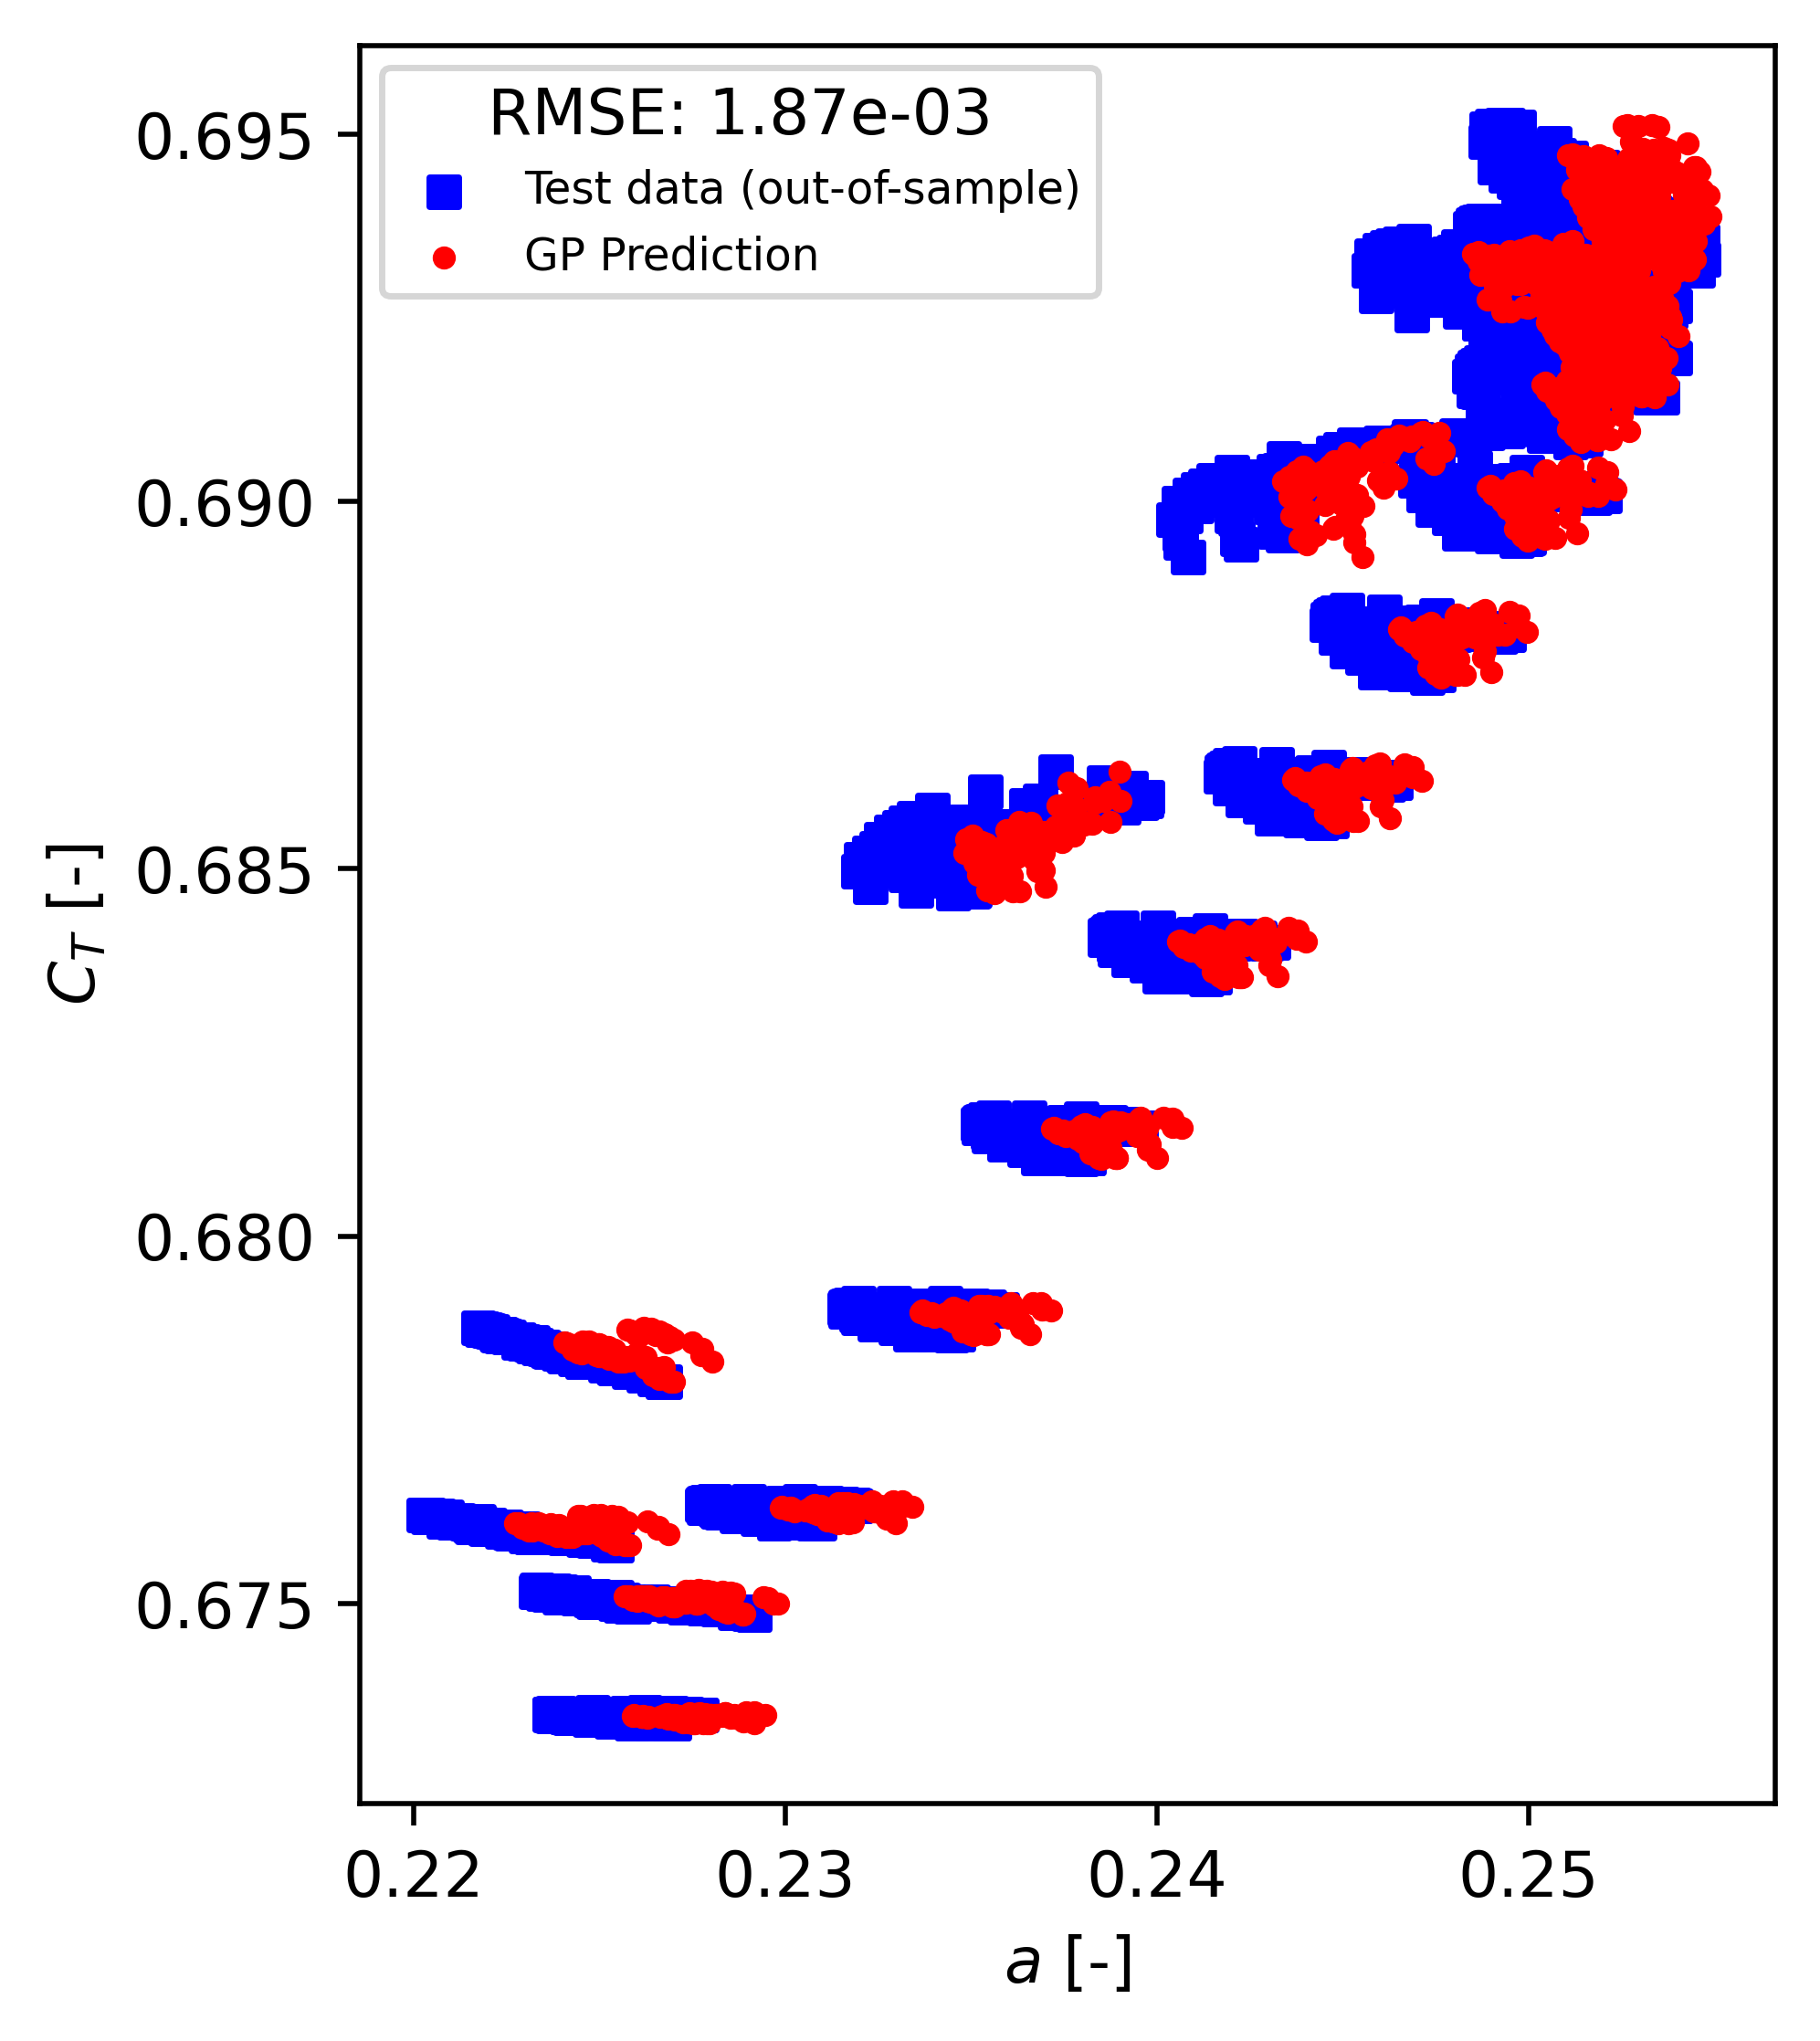

In [10]:
out_sample = np.array([0,1,2,3,4,5,6,7,8,9,10,19,20,29,30,39,40,49,50,69,70,79,80,81,82,83,84,85,86,87,88,89])
full_range = np.arange(0, 90)  # inclusive of 90
in_sample = np.setdiff1d(full_range, out_sample)

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(4, 5))

# ax.plot(a_mom,ct_mom,'#ff3c00',zorder=1)
# ax.plot(a_mad,ct_mad,'k--',zorder=1)
# ax.scatter(y_train,X_train[:,0],color='b')

ax.scatter(y_t_rot, X_t_rot[:, 1], s=20, color='b', marker='s', label='Test data (out-of-sample)')
# ax.scatter(y_t_rot[out_sample], X_t_rot[out_sample, 0], s=20, color='b', marker='s', label='Test data (out-of-sample)')
# ax.scatter(y_t_rot[in_sample], X_t_rot[in_sample, 0], s=20, color='b', marker='o', label='Test data (in-sample)')

ax.scatter(A_pred,X_t_rot[:,1],7,color='r', label = 'GP Prediction')

# ax.set_xlim([0.21,0.28])
# ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

rmse = np.sqrt(mean_squared_error(y_t_rot, A_pred))
ax.legend(fontsize=7, title=f"RMSE: {rmse:.2e}")

In [35]:
rmse

np.float64(0.001606680491155459)

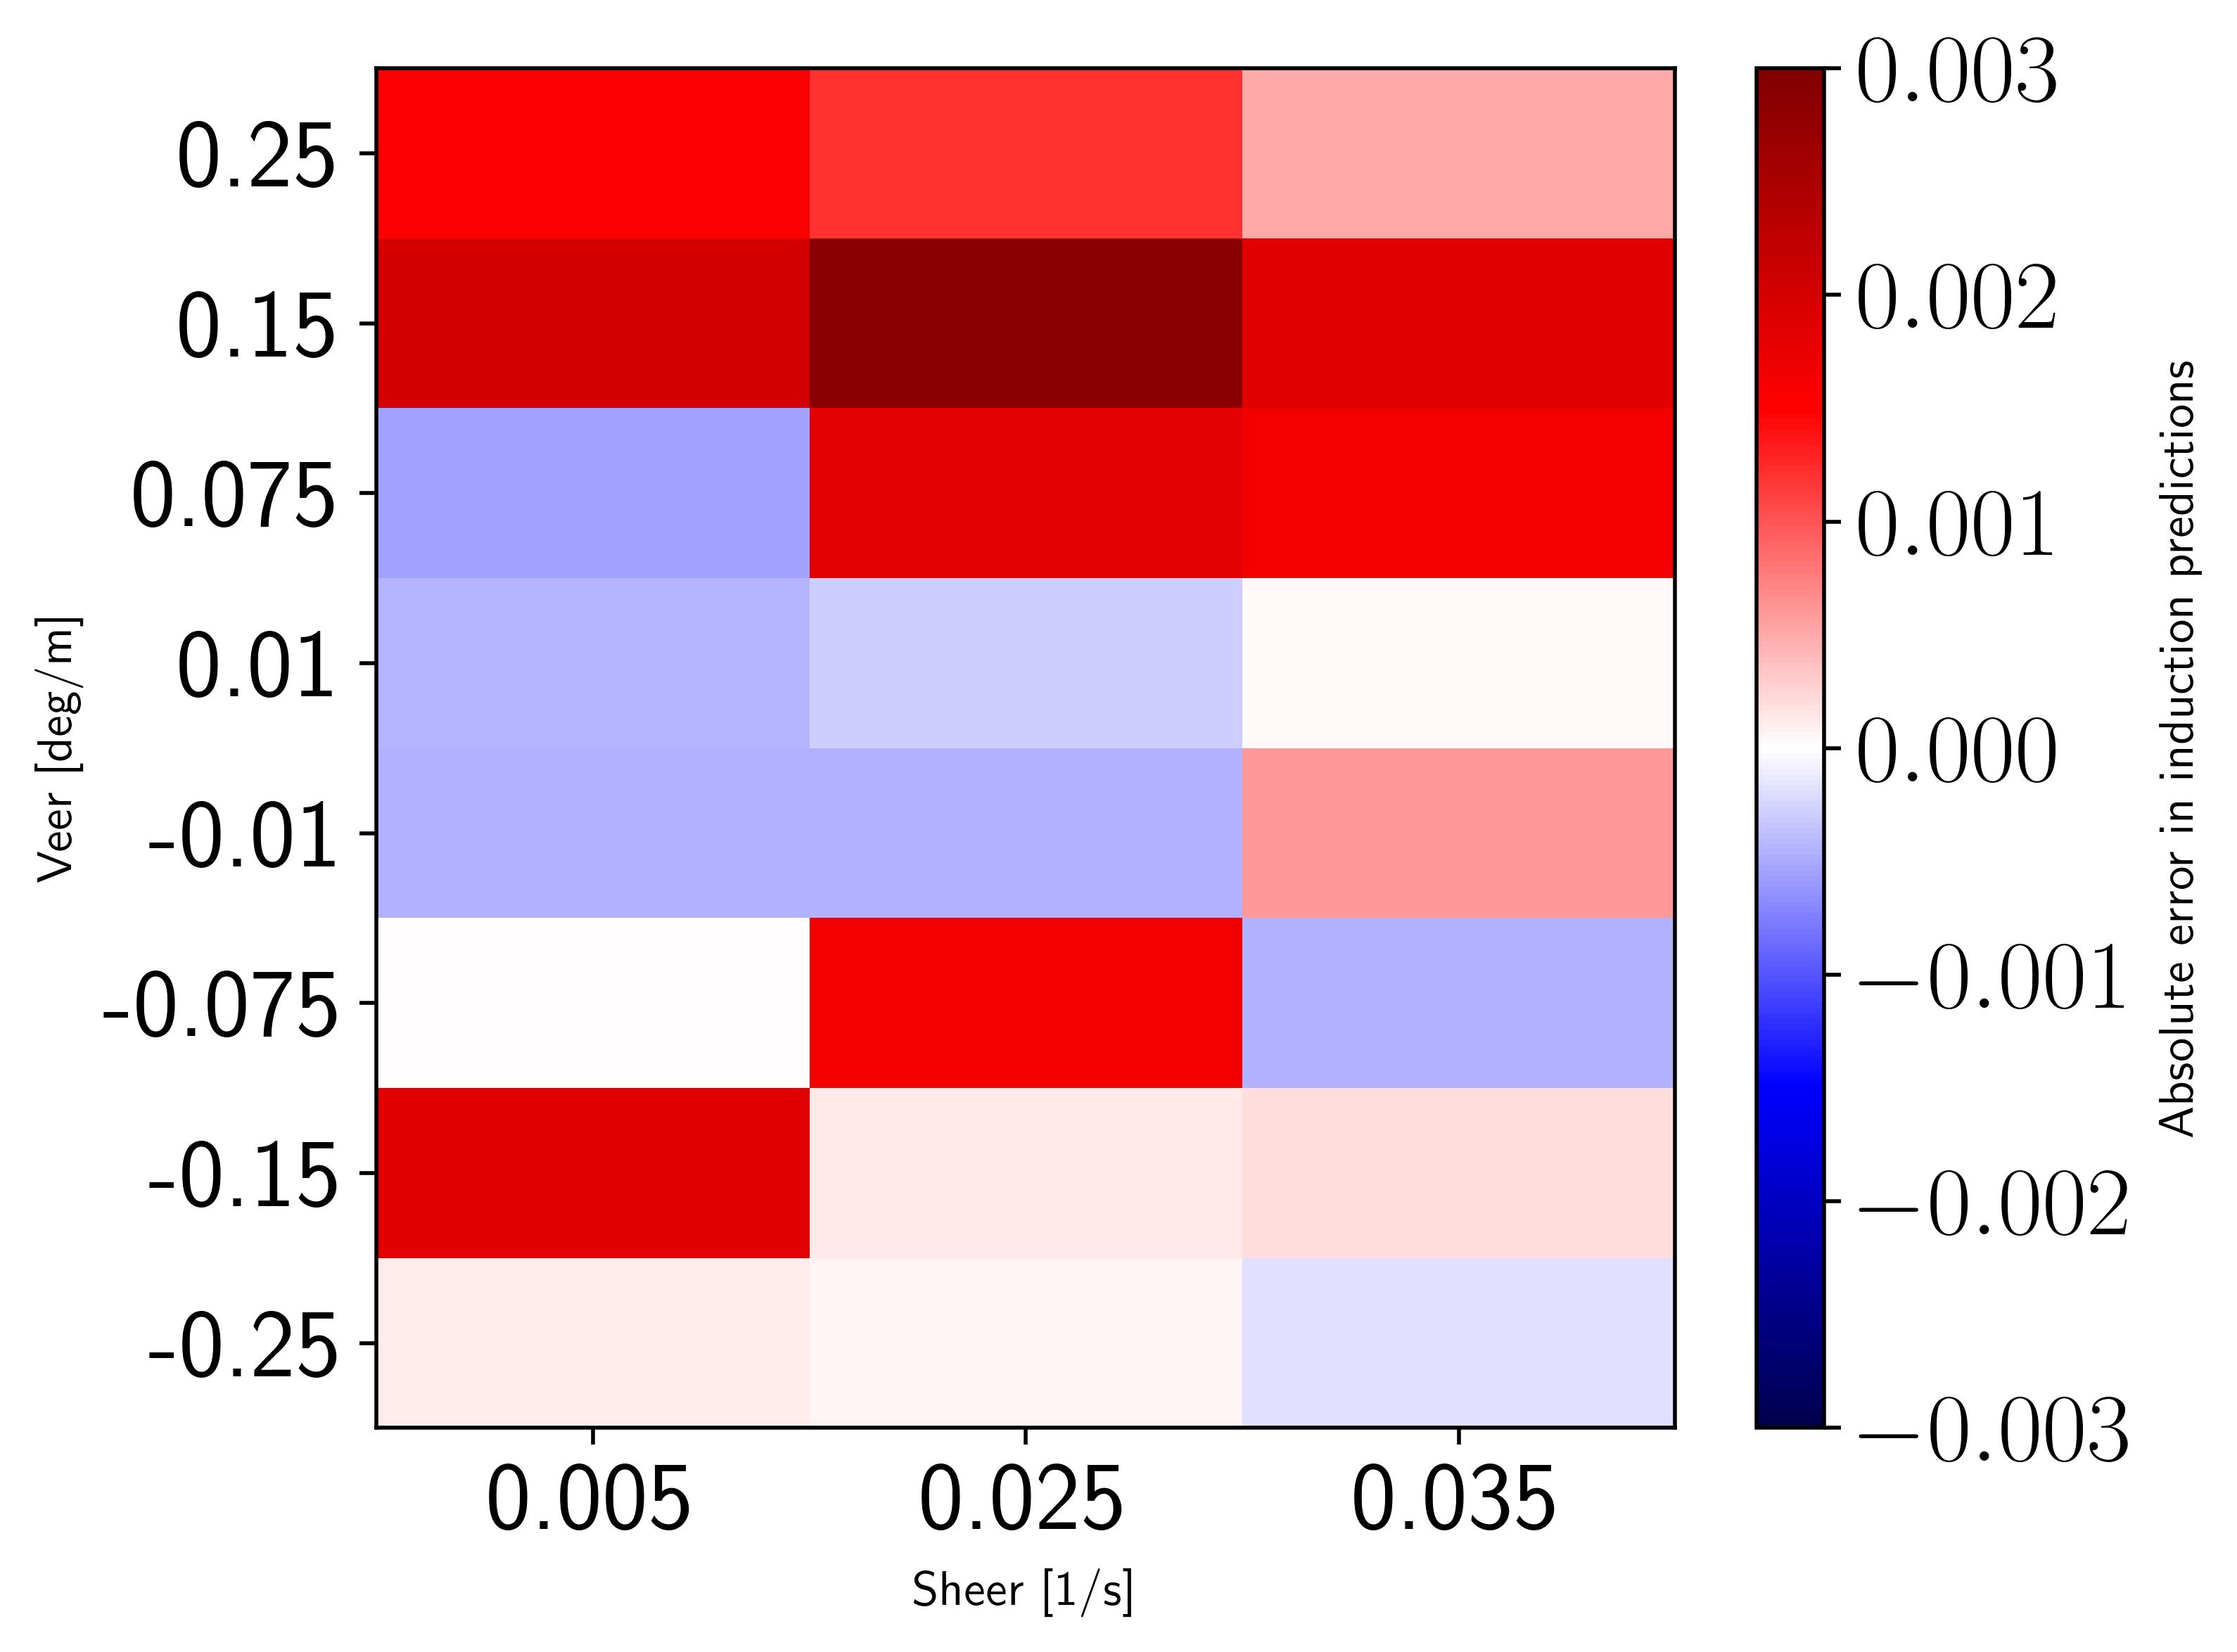

In [182]:
import numpy as np
import matplotlib.pyplot as plt

# Example 2D data
data = (y_test - A_pred).reshape(8,3)
# data = A_pred.reshape(8,3)


# Define the edges of the grid (must be one more than data.shape)
x_edges = np.arange(data.shape[1] + 1)  # 4 edges for 3 columns
y_edges = np.arange(data.shape[0] + 1)  # 5 edges for 4 rows

r's035_v010',
r's035_v075',
r's035_v150',
r's035_v250',
r's035_vn010',
r's035_vn075',
r's035_vn150',
r's035_vn250',

# Define tick labels you want to appear at cell centers
x_tick_labels = ['0.005', '0.025', '0.035']
y_tick_labels = ['-0.25','-0.15','-0.075','-0.01','0.01','0.075','0.15','0.25']

# Compute centers of the grid cells (midpoints between edges)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

# Set custom tick locations (centers of cells)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

# Plot
fig, ax = plt.subplots()
mesh = ax.pcolormesh(x_edges, y_edges, data, shading='auto', cmap='seismic',vmin=-0.003,vmax=0.003)

# Set ticks at cell centers
ax.set_xticks(x_centers)
ax.set_xticklabels(x_tick_labels)

ax.set_yticks(y_centers)
ax.set_yticklabels(y_tick_labels)

# Optional: add a colorbar
plt.colorbar(mesh, ax=ax, label='Absolute error in induction predictions')
plt.ylabel('Veer [deg/m]')
plt.xlabel('Sheer [1/s]')
plt.tight_layout()
plt.show()

In [167]:
data

array([[ 1.15015338e-04,  6.17230698e-05, -1.84967757e-04],
       [ 1.85704842e-03,  1.30309843e-04,  2.09168802e-04],
       [ 1.77425064e-05,  1.64617297e-03, -4.59429252e-04],
       [-4.67581334e-04, -4.47170470e-04,  5.99205096e-04],
       [-4.36760437e-04, -3.03059934e-04,  4.23056248e-05],
       [-5.56503308e-04,  1.82728353e-03,  1.64561741e-03],
       [ 2.01242809e-03,  2.86916226e-03,  1.85984577e-03],
       [ 1.55106164e-03,  1.20155882e-03,  5.00825900e-04]])

In [92]:
A_pred

array([0.25194899, 0.24890544, 0.24874281, 0.24912277, 0.2498527 ,
       0.25097282, 0.25247105, 0.25648237, 0.26755682])